# Step 04 — Regime Profiling

This notebook explores the regime profiles produced by `pipelines/04_regime_label.py`.
Each cluster is assigned an economic name (e.g. Stagflation, Growth Boom) and
characterised by its distribution of key macro indicators.

Key outputs:
- **Regime timeline** — which regime was active each quarter
- **Transition matrix** — probability of moving from one regime to another
- **Indicator profiles** — box-plot distributions of key variables per regime

**Run `python pipelines/04_regime_label.py` before executing this notebook.**

## Setup & Imports

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "../src")
import logging
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from market_regime.config import load, setup_logging
from market_regime.runtime import RunConfig
from market_regime import DATA_DIR, plotting
setup_logging("INFO")
log = logging.getLogger("04_regimes")
cfg = load()
run_cfg = RunConfig(generate_plots=True, save_plots=True, show_plots=False)

In [2]:
import subprocess
from pathlib import Path

def run_step_if_needed(step: int, required_paths: list, auto_run: bool = True) -> bool:
    """Run the pipeline step if any required output files are missing."""
    missing = [p for p in required_paths if not Path(p).exists()]
    if not missing:
        return True
    print(f"Missing: {[str(p) for p in missing]}")
    scripts = sorted(Path("../pipelines").glob(f"{step:02d}_*.py"))
    if not scripts:
        print(f"No pipeline script found for step {step}.")
        return False
    script = scripts[0]
    if not auto_run:
        print(f"  → Run: python {script}")
        return False
    print(f"  → Running {script.name} ...")
    result = subprocess.run(["python", str(script)], capture_output=True, text=True, cwd="..")
    out = result.stdout
    if len(out) > 4000:
        out = out[:2000] + "\n...\n" + out[-2000:]
    print(out)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
        return False
    print(f"  ✓ Step {step} complete.")
    return True

# Run regime labeling step if transition matrix is missing
run_step_if_needed(4, [DATA_DIR / "regimes" / "transition_matrix.parquet"])

True

## Load Cluster Labels, Features, Regime Names, and Transition Matrix

In [3]:
REGIMES_DIR = DATA_DIR / "regimes"
PROCESSED_DIR = DATA_DIR / "processed"

labels = None
features = None
tm = None
regime_names = {}

# Cluster labels
try:
    labels_df = pd.read_parquet(REGIMES_DIR / "cluster_labels.parquet")
    # Use balanced_cluster as the primary assignment
    if "balanced_cluster" in labels_df.columns:
        labels = labels_df["balanced_cluster"]
    elif "cluster" in labels_df.columns:
        labels = labels_df["cluster"]
        print("Note: using 'cluster' (balanced_cluster not found)")
    print(f"Labels loaded: {len(labels)} quarters")
except FileNotFoundError:
    print("ERROR: cluster_labels.parquet not found. Run pipelines/03_cluster.py first.")

# Feature matrix
try:
    features = pd.read_parquet(PROCESSED_DIR / "features.parquet")
    print(f"Features loaded: {features.shape}")
except FileNotFoundError:
    print("ERROR: features.parquet not found. Run pipelines/02_features.py first.")

# Transition matrix
try:
    tm = pd.read_parquet(REGIMES_DIR / "transition_matrix.parquet")
    print(f"Transition matrix loaded: {tm.shape}")
except FileNotFoundError:
    print("ERROR: transition_matrix.parquet not found. Run pipelines/04_regime_label.py first.")

Labels loaded: 304 quarters
Features loaded: (305, 71)
Transition matrix loaded: (5, 5)


## Load Regime Names

Suggested names are stored in `data/regimes/regime_names_suggested.yaml`
after running `pipelines/04_regime_label.py`. Edit `config/regime_labels.yaml`
to override with manually pinned names.

In [4]:
# Try suggested names first, then fall back to manually pinned labels
names_candidates = [
    REGIMES_DIR / "regime_names_suggested.yaml",
    DATA_DIR.parent / "config" / "regime_labels.yaml",
]

for path in names_candidates:
    try:
        with open(path) as f:
            raw_names = yaml.safe_load(f)
        # Normalize keys to int
        regime_names = {int(k): str(v) for k, v in raw_names.items()}
        print(f"Regime names loaded from {path}:")
        for k, v in sorted(regime_names.items()):
            print(f"  Regime {k}: {v}")
        break
    except FileNotFoundError:
        continue
    except Exception as exc:
        print(f"Warning: could not load {path}: {exc}")
        continue

if not regime_names:
    print("No regime names file found — using generic names (Regime 0, Regime 1, ...)")
    if labels is not None:
        unique = sorted(labels.dropna().astype(int).unique())
        regime_names = {i: f"Regime {i}" for i in unique}

Regime names loaded from /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../data/regimes/regime_names_suggested.yaml:
  Regime 0: High Inflation / Rising CPI / Strong Growth
  Regime 1: Falling CPI / GDP Contracting / Rates Falling
  Regime 2: Rising CPI / Strong Growth / Strong Real Growth
  Regime 3: Falling CPI / Weak/Neg Growth / Weak Real Growth
  Regime 4: Low Inflation / Falling CPI / Strong Real Growth


## Regime Timeline

Horizontal strip chart showing which regime was active each quarter.
Each row is one regime; coloured bands indicate active periods.

2026-03-10 15:35:20 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/04_regime_timeline.png


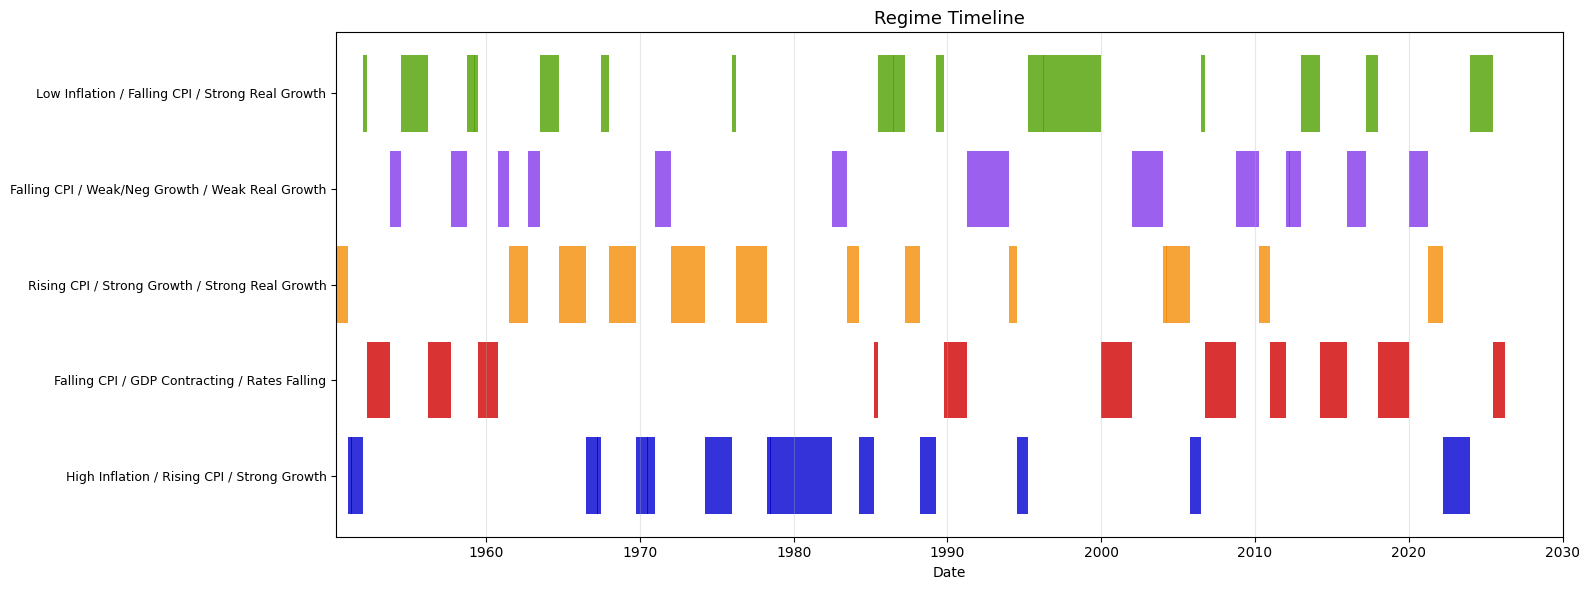

In [5]:
if labels is not None:
    plotting.plot_regime_timeline(labels, regime_names, run_cfg)

## Transition Matrix

Heatmap of regime transition probabilities. The diagonal represents regime
persistence (probability of staying in the same regime next quarter).
High off-diagonal values indicate common regime transitions.

2026-03-10 15:35:21 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/04_transition_matrix.png


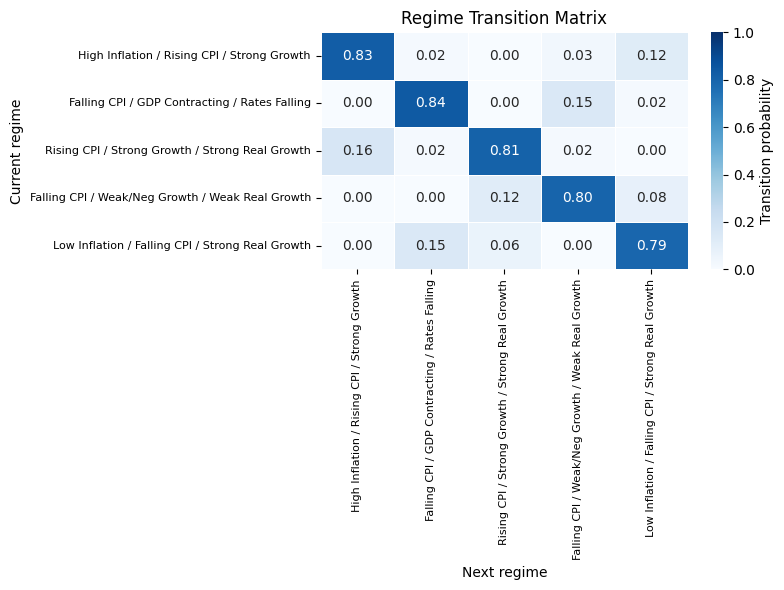

In [6]:
if tm is not None:
    plotting.plot_transition_matrix(tm, regime_names, run_cfg)

## Key Indicator Profiles

Box plots for a set of key economic indicators across regimes.
These distributions help validate that the regime names assigned
in the previous step are economically meaningful.

In [ ]:
# Key indicators to profile per regime.
# Defined in config/settings.yaml under plotting.key_indicators.
# Edit that list to add/remove indicators — no notebook code change needed.
# Note: only derivatives of 10yr_ustreas exist in features (10yr_ustreas_d1, _d2).
KEY_INDICATORS = cfg.get("plotting", {}).get("key_indicators", [
    "us_infl", "credit_spread", "gdp_growth", "real_gdp_growth",
    "sp500_pe", "10yr_ustreas_d1",
])

if features is not None and labels is not None:
    available = [c for c in KEY_INDICATORS if c in features.columns]
    missing   = [c for c in KEY_INDICATORS if c not in features.columns]
    if missing:
        print(f"Note: key_indicators not found in features: {missing}")
        print("Check config/settings.yaml plotting.key_indicators — using available columns only.")
    if available:
        aligned_labels = labels.reindex(features.index).dropna()
        aligned_features = features.loc[aligned_labels.index]
        plotting.plot_regime_profiles(aligned_features, aligned_labels, regime_names, available, run_cfg)
    else:
        print("None of the requested key indicators found in features. Available columns:")
        print(list(features.columns[:20]))

## Transition Matrix Table

In [8]:
if tm is not None:
    print("Regime Transition Probability Matrix:")
    print("(rows = current regime, columns = next regime)")
    print()
    # Rename index/columns to regime names for readability
    tm_named = tm.copy()
    tm_named.index   = [regime_names.get(int(i), f"R{i}") for i in tm.index]
    tm_named.columns = [regime_names.get(int(c), f"R{c}") for c in tm.columns]
    display(tm_named.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None))

Regime Transition Probability Matrix:
(rows = current regime, columns = next regime)



,High Inflation / Rising CPI / Strong Growth,Falling CPI / GDP Contracting / Rates Falling,Rising CPI / Strong Growth / Strong Real Growth,Falling CPI / Weak/Neg Growth / Weak Real Growth,Low Inflation / Falling CPI / Strong Real Growth
High Inflation / Rising CPI / Strong Growth,0.828,0.017,0.000,0.034,0.121
Falling CPI / GDP Contracting / Rates Falling,0.000,0.836,0.000,0.148,0.016
Rising CPI / Strong Growth / Strong Real Growth,0.161,0.016,0.806,0.016,0.000
Falling CPI / Weak/Neg Growth / Weak Real Growth,0.000,0.000,0.117,0.800,0.083
Low Inflation / Falling CPI / Strong Real Growth,0.000,0.145,0.065,0.000,0.790


## Regime Summary

In [11]:
if labels is not None:
    counts = labels.dropna().astype(int).value_counts().sort_index()
    total  = counts.sum()

    print(f"{'ID':>4}  {'Name':<50}  {'Count':>6}  {'Pct':>7}")
    print("-" * 78)
    for cid, count in counts.items():
        name = regime_names.get(cid, f"Regime {cid}")
        pct  = count / total * 100
        print(f"  {cid:>2}  {name:<50}  {count:>6}  {pct:>6.1f}%")
    print("-" * 78)
    print(f"  {'':>2}  {'TOTAL':<50}  {total:>6}  {100.0:>6.1f}%")

  ID  Name                                                 Count      Pct
------------------------------------------------------------------------------
   0  High Inflation / Rising CPI / Strong Growth             58    19.1%
   1  Falling CPI / GDP Contracting / Rates Falling           62    20.4%
   2  Rising CPI / Strong Growth / Strong Real Growth         62    20.4%
   3  Falling CPI / Weak/Neg Growth / Weak Real Growth        60    19.7%
   4  Low Inflation / Falling CPI / Strong Real Growth        62    20.4%
------------------------------------------------------------------------------
      TOTAL                                                  304   100.0%
